# Jour 3 — TP : votre analyse, votre angle

## L'objectif

Hier, vous avez répondu à des questions. Aujourd'hui, **vous posez la vôtre**.

Choisissez un angle que vous n'avez pas exploré les deux premiers jours et creusez-le en autonomie.
En fin de journée, vous présentez votre travail au groupe et vous défendez vos choix techniques.

## Trouver votre angle

**Première piste** : relisez la section « Limites et pistes » de votre rapport d'hier. Vous y avez déjà écrit ce qu'il restait à faire.

Un bon angle est une question à laquelle votre rapport d'hier ne répond pas, et dont la réponse changerait une décision. Quelques directions :

- **croiser trois dimensions** au lieu de deux (qui × quoi × quand) ;
- **une dimension absente** de votre rapport : le temps, la géographie, le profil client ;
- **segmenter** : vos clients, vos produits ou vos périodes se comportent-ils tous pareil ?
- **creuser une anomalie** repérée hier sans l'expliquer ;
- **changer d'unité** : passer du total au par-jour, au par-client, au par-vente.

Un mauvais angle : refaire une analyse d'hier avec un graphique plus joli, ou empiler des tableaux sans question derrière.

**Formulez votre problématique en une phrase avant d'écrire la moindre ligne de code.** Si vous n'y arrivez pas, l'angle n'est pas encore clair.

## Attendu en fin de journée

- Votre **problématique**, en une phrase, en tête du notebook
- **2 à 4 analyses** qui y répondent : tableau, graphique, commentaire en trois temps
- Une **conclusion** : ce que vous avez trouvé, et ce que vous feriez avec plus de temps
- Un notebook qui s'exécute **du début à la fin sans erreur** (*Kernel → Restart & Run All*), commité et poussé

## Les règles qui restent valables

- Le titre d'un graphique **énonce le message** ; il ne contredit jamais le tableau au-dessus.
- Un taux global est un **ratio de sommes**, jamais une moyenne de taux.
- **Normalisez avant de comparer** : au jour, à la vente, au client. Comparer des totaux entre populations de tailles différentes produit des conclusions fausses qui ont l'air justes.
- **Vérifiez l'effectif** derrière chaque pourcentage : 25 % sur 4 personnes, c'est une personne.
- `nunique` pour des clients, `count` pour des lignes.
- Dites ce que vous ne pouvez pas conclure. Une limite assumée vaut mieux qu'une affirmation fragile.

## La revue individuelle — 10 minutes

Préparez-vous à répondre à :
- Pourquoi ce graphique plutôt qu'un autre ?
- Ce chiffre, il est calculé sur quelle population exactement ?
- Que signifie ce résultat, concrètement, pour l'activité ?
- **Qu'est-ce qui pourrait rendre cette conclusion fausse ?**

## La restitution — 10 minutes

Vous déroulez **votre notebook en direct**, pas de slides.

| Temps | Contenu |
|---|---|
| 1 min | Votre problématique et pourquoi elle est intéressante |
| 3 min | Votre démarche : données retenues, traitements, choix faits |
| 4 min | Vos résultats et ce qu'il faut en retenir |
| 2 min | Vos limites et la suite |

**Évaluation (sur 20)**

| Critère | Points |
|---|---|
| Clarté de la problématique | 4 |
| Justesse technique et choix assumés | 6 |
| Lisibilité des graphiques et du notebook | 5 |
| Qualité des réponses aux questions | 5 |

## Checklist avant de rendre

- [ ] La problématique est écrite en une phrase, en tête du notebook
- [ ] Chaque analyse a son tableau, son graphique et son commentaire en trois temps
- [ ] Chaque graphique a un titre-message, des axes nommés et des unités
- [ ] Les effectifs derrière les pourcentages sont vérifiés
- [ ] Le notebook tourne entièrement après *Restart & Run All*
- [ ] Le code est commenté, les cellules inutiles supprimées
- [ ] Conclusion et limites rédigées
- [ ] Commit + push effectués

---

# Fidélisation client : quels premiers achats génèrent un réachat rentable à 90 jours ?

**Groupe : Jacques Callewaert**

## Problématique

> **Quels profils de primo-clients transforment le mieux leur premier achat en réachat rentable dans les 90 jours, selon leur canal d'acquisition, leur catégorie d'entrée et la remise reçue ?**

### Pourquoi cette question est intéressante ?

Le chiffre d'affaires d'une première commande ne suffit pas à mesurer la valeur d'un client.  
Un client devient plus intéressant s'il revient acheter et s'il génère suffisamment de marge.

Cette analyse cherche donc à identifier les caractéristiques associées à la fidélisation afin d'aider l'entreprise à mieux orienter ses actions commerciales et marketing.

### Périmètre

- seules les commandes au statut **Livrée** sont retenues ;
- l'unité principale d'analyse est le **client unique** ;
- un réachat correspond à une deuxième commande livrée dans les **90 jours** suivant la première ;
- seuls les clients disposant réellement de 90 jours d'observation sont inclus dans l'analyse de fidélisation ;
- la performance économique est étudiée avec le **chiffre d'affaires net et la marge**.


## Préparation des données

In [1]:
# JOUR 3 - FIDÉLISATION CLIENT À 90 JOURS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display, Markdown


# Style des graphiques


sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# Chargement des fichiers

DATA_DIR = Path("data")

commandes = pd.read_csv(DATA_DIR / "commandes.csv")
produits = pd.read_csv(DATA_DIR / "produits.csv")
clients = pd.read_csv(DATA_DIR / "clients.csv")


print("Dimensions des fichiers :")
print(f"Commandes : {commandes.shape}")
print(f"Produits  : {produits.shape}")
print(f"Clients   : {clients.shape}")

Dimensions des fichiers :
Commandes : (6500, 8)
Produits  : (40, 5)
Clients   : (1200, 5)


In [2]:
# CONTRÔLE DE LA STRUCTURE DES DONNÉES

# Nettoyage des noms de colonnes
commandes.columns = (
    commandes.columns
    .str.strip()
    .str.lower()
)

produits.columns = (
    produits.columns
    .str.strip()
    .str.lower()
)

clients.columns = (
    clients.columns
    .str.strip()
    .str.lower()
)


# Colonnes réellement attendues
colonnes_commandes = {
    "commande_id",
    "date_commande",
    "client_id",
    "produit_id",
    "quantite",
    "remise",
    "statut",
    "mode_paiement"
}

colonnes_produits = {
    "produit_id",
    "nom_produit",
    "categorie",
    "prix_unitaire",
    "cout_unitaire"
}

colonnes_clients = {
    "client_id",
    "ville",
    "age",
    "canal_acquisition",
    "date_inscription"
}


# Vérifications
assert colonnes_commandes.issubset(commandes.columns), \
    f"Colonnes manquantes dans commandes : {colonnes_commandes - set(commandes.columns)}"

assert colonnes_produits.issubset(produits.columns), \
    f"Colonnes manquantes dans produits : {colonnes_produits - set(produits.columns)}"

assert colonnes_clients.issubset(clients.columns), \
    f"Colonnes manquantes dans clients : {colonnes_clients - set(clients.columns)}"


# Vérification des clés
assert produits["produit_id"].is_unique, \
    "Erreur : produit_id n'est pas unique dans produits.csv"

assert clients["client_id"].is_unique, \
    "Erreur : client_id n'est pas unique dans clients.csv"


print("✅ Structure des fichiers validée")

print("\nColonnes commandes :")
print(commandes.columns.tolist())

print("\nColonnes produits :")
print(produits.columns.tolist())

print("\nColonnes clients :")
print(clients.columns.tolist())

✅ Structure des fichiers validée

Colonnes commandes :
['commande_id', 'date_commande', 'client_id', 'produit_id', 'quantite', 'remise', 'statut', 'mode_paiement']

Colonnes produits :
['produit_id', 'nom_produit', 'categorie', 'prix_unitaire', 'cout_unitaire']

Colonnes clients :
['client_id', 'ville', 'age', 'canal_acquisition', 'date_inscription']


In [3]:
# JOINTURES ET PRÉPARATION

df = (
    commandes
    .merge(
        produits[
            [
                "produit_id",
                "nom_produit",
                "categorie",
                "prix_unitaire",
                "cout_unitaire"
            ]
        ],
        on="produit_id",
        how="left",
        validate="m:1"
    )
    .merge(
        clients[
            [
                "client_id",
                "ville",
                "age",
                "canal_acquisition",
                "date_inscription"
            ]
        ],
        on="client_id",
        how="left",
        validate="m:1"
    )
)

print(f" Jointure terminée : {len(df):,} lignes")

# Dates

df["date_commande"] = pd.to_datetime(
    df["date_commande"],
    errors="coerce"
)

df["date_inscription"] = pd.to_datetime(
    df["date_inscription"],
    errors="coerce"
)


# Variables numériques

for col in [
    "quantite",
    "remise",
    "prix_unitaire",
    "cout_unitaire",
    "age"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# Gestion de la remise


df["remise_taux"] = (
    df["remise"]
    .fillna(0)
    .copy()
)

# Sécurité si la remise est un jour écrite 10 au lieu de 0.10
if df["remise_taux"].max() > 1:
    df["remise_taux"] = (
        df["remise_taux"] / 100
    )

assert df["remise_taux"].between(0, 1).all(), \
    "Erreur : certaines remises sont hors de l'intervalle 0-100 %"



# Indicateurs économiques

df["ca_brut"] = (
    df["quantite"]
    * df["prix_unitaire"]
)

df["ca"] = (
    df["ca_brut"]
    * (1 - df["remise_taux"])
)

df["cout"] = (
    df["quantite"]
    * df["cout_unitaire"]
)

df["marge"] = (
    df["ca"]
    - df["cout"]
)


# Nettoyage du statut


df["statut_norm"] = (
    df["statut"]
    .astype(str)
    .str.strip()
    .str.casefold()
)



# Conservation des commandes livrées uniquement

ventes = df[
    df["statut_norm"].eq("livrée".casefold())
].copy()


assert not ventes.empty, \
    "Aucune commande livrée n'a été trouvée."


print("\n PÉRIMÈTRE RETENU ")

print(
    f" {len(ventes):,} lignes de produits livrés"
)

print(
    f" {ventes['commande_id'].nunique():,} commandes livrées"
)

print(
    f" {ventes['client_id'].nunique():,} clients uniques"
)

print(
    f" CA net total : {ventes['ca'].sum():,.2f} €"
)

print(
    f" Marge totale : {ventes['marge'].sum():,.2f} €"
)

 Jointure terminée : 6,500 lignes

 PÉRIMÈTRE RETENU 
 5,886 lignes de produits livrés
 5,886 commandes livrées
 984 clients uniques
 CA net total : 642,688.78 €
 Marge totale : 232,616.59 €


## Préparation des données

Les trois fichiers ont été reliés grâce aux identifiants `produit_id` et `client_id`.

Le prix de vente et le coût unitaire provenant du fichier produits, le chiffre d'affaires net d'une ligne est calculé comme :

**CA net = quantité x prix unitaire x (1 - remise)**

La marge est ensuite définie comme :

**Marge = chiffre d'affaires net - coût des produits**

Les commandes non livrées sont exclues afin de ne pas comptabiliser comme revenu une transaction annulée ou non finalisée.

In [4]:
# PASSAGE DE LA LIGNE PRODUIT À LA COMMANDE


commandes_livrees = (
    ventes
    .groupby(
        [
            "commande_id",
            "client_id",
            "date_commande"
        ],
        as_index=False
    )
    .agg(
        ca=("ca", "sum"),
        ca_brut=("ca_brut", "sum"),
        marge=("marge", "sum"),
        quantite=("quantite", "sum")
    )
)


# Remise réellement supportée par la commande
commandes_livrees["remise_effective"] = np.where(
    commandes_livrees["ca_brut"] > 0,
    1 - (
        commandes_livrees["ca"]
        / commandes_livrees["ca_brut"]
    ),
    0
)


# Tri chronologique
commandes_livrees = (
    commandes_livrees
    .sort_values(
        [
            "client_id",
            "date_commande",
            "commande_id"
        ]
    )
    .reset_index(drop=True)
)


# Rang de la commande dans la vie du client
commandes_livrees["rang_client"] = (
    commandes_livrees
    .groupby("client_id")
    .cumcount()
    + 1
)


print(
    f" Table commandes : {len(commandes_livrees):,} commandes"
)

display(
    commandes_livrees.head()
)

 Table commandes : 5,886 commandes


,commande_id,client_id,date_commande,ca,ca_brut,marge,quantite,remise_effective,rang_client
0,CMD00308,C0001,2025-01-21 04:44:00,82.180,82.18,47.880,2,0.0,1
1,CMD00955,C0001,2025-03-09 20:47:00,41.090,41.09,23.940,1,0.0,2
2,CMD00996,C0001,2025-03-12 20:13:00,176.560,176.56,76.340,2,0.0,3
3,CMD01340,C0001,2025-04-02 13:18:00,60.720,60.72,38.350,1,0.0,4
4,CMD02955,C0001,2025-07-13 12:00:00,54.648,60.72,32.278,1,0.1,5


In [5]:
# PREMIÈRE ET DEUXIÈME COMMANDE DE CHAQUE CLIENT

premiere_commande = (
    commandes_livrees[
        commandes_livrees["rang_client"] == 1
    ][
        [
            "client_id",
            "commande_id",
            "date_commande",
            "ca",
            "marge",
            "remise_effective"
        ]
    ]
    .rename(
        columns={
            "commande_id": "premiere_commande_id",
            "date_commande": "date_premiere",
            "ca": "ca_premiere",
            "marge": "marge_premiere",
            "remise_effective": "remise_premiere"
        }
    )
)


deuxieme_commande = (
    commandes_livrees[
        commandes_livrees["rang_client"] == 2
    ][
        [
            "client_id",
            "date_commande"
        ]
    ]
    .rename(
        columns={
            "date_commande": "date_deuxieme"
        }
    )
)


profil_client = (
    premiere_commande
    .merge(
        deuxieme_commande,
        on="client_id",
        how="left"
    )
)


# Ajout des caractéristiques client
profil_client = profil_client.merge(
    clients[
        [
            "client_id",
            "ville",
            "age",
            "canal_acquisition"
        ]
    ],
    on="client_id",
    how="left",
    validate="1:1"
)


display(
    profil_client.head()
)

,client_id,premiere_commande_id,date_premiere,ca_premiere,marge_premiere,remise_premiere,date_deuxieme,ville,age,canal_acquisition
0,C0001,CMD00308,2025-01-21 04:44:00,82.180,47.880,0.0,2025-03-09 20:47:00,Bordeaux,51,Publicité en ligne
1,C0002,CMD00200,2025-01-13 20:20:00,58.743,31.143,0.1,NaT,Paris,39,Moteur de recherche
2,C0004,CMD01937,2025-05-10 14:04:00,133.620,59.920,0.0,NaT,Paris,18,Publicité en ligne
3,C0005,CMD00741,2025-02-23 21:17:00,36.981,19.831,0.1,2025-04-04 21:08:00,Lille,36,Bouche-à-oreille
4,C0006,CMD02780,2025-07-01 01:05:00,32.740,18.710,0.0,2025-09-17 22:01:00,Marseille,19,Publicité en ligne


In [6]:
# CONSTRUCTION D'UNE FENÊTRE DE 90 JOURS


date_fin_dataset = (
    commandes_livrees["date_commande"].max()
)

date_limite_entree = (
    date_fin_dataset
    - pd.Timedelta(days=90)
)


# Seuls les clients dont la première commande date
# d'au moins 90 jours avant la fin du dataset sont comparables
profil_client["eligible_90j"] = (
    profil_client["date_premiere"]
    <= date_limite_entree
)


# Réachat dans les 90 jours
profil_client["reachat_90j"] = (
    profil_client["date_deuxieme"].notna()
    &
    (
        profil_client["date_deuxieme"]
        <= profil_client["date_premiere"]
        + pd.Timedelta(days=90)
    )
)


# Délai avant le deuxième achat
profil_client["delai_reachat_jours"] = (
    profil_client["date_deuxieme"]
    - profil_client["date_premiere"]
).dt.days


clients_eligibles = (
    profil_client[
        profil_client["eligible_90j"]
    ]
    .copy()
)


print(
    "Dernière date du dataset :",
    date_fin_dataset.date()
)

print(
    "Dernière première commande admissible :",
    date_limite_entree.date()
)

print(
    f"Clients totaux : {len(profil_client):,}"
)

print(
    f"Clients avec 90 jours complets : {len(clients_eligibles):,}"
)

Dernière date du dataset : 2025-12-31
Dernière première commande admissible : 2025-10-02
Clients totaux : 984
Clients avec 90 jours complets : 880


### Choix méthodologique : pourquoi une fenêtre de 90 jours ?

Un client ayant effectué son premier achat quelques jours avant la fin du dataset n'a pas eu autant de temps pour racheter qu'un client présent depuis plusieurs mois.

Le classer immédiatement comme « non fidèle » créerait donc un biais.

Pour comparer les clients équitablement, seuls ceux disposant d'au moins **90 jours complets d'observation** après leur première commande sont utilisés pour mesurer le réachat.

In [7]:
# VALEUR ÉCONOMIQUE DES CLIENTS SUR 90 JOURS

commandes_avec_depart = (
    commandes_livrees
    .merge(
        profil_client[
            [
                "client_id",
                "date_premiere"
            ]
        ],
        on="client_id",
        how="left",
        validate="m:1"
    )
)


dans_90_jours = (
    (commandes_avec_depart["date_commande"]
     >= commandes_avec_depart["date_premiere"])
    &
    (commandes_avec_depart["date_commande"]
     <= commandes_avec_depart["date_premiere"]
     + pd.Timedelta(days=90))
)


valeur_90j = (
    commandes_avec_depart[
        dans_90_jours
    ]
    .groupby(
        "client_id",
        as_index=False
    )
    .agg(
        nb_commandes_90j=(
            "commande_id",
            "nunique"
        ),
        ca_90j=(
            "ca",
            "sum"
        ),
        marge_90j=(
            "marge",
            "sum"
        )
    )
)


clients_eligibles = (
    clients_eligibles
    .merge(
        valeur_90j,
        on="client_id",
        how="left",
        validate="1:1"
    )
)


display(
    clients_eligibles.head()
)

,client_id,premiere_commande_id,date_premiere,ca_premiere,marge_premiere,remise_premiere,date_deuxieme,ville,age,canal_acquisition,eligible_90j,reachat_90j,delai_reachat_jours,nb_commandes_90j,ca_90j,marge_90j
0,C0001,CMD00308,2025-01-21 04:44:00,82.180,47.880,0.0,2025-03-09 20:47:00,Bordeaux,51,Publicité en ligne,True,True,47.0,4,360.550,186.510
1,C0002,CMD00200,2025-01-13 20:20:00,58.743,31.143,0.1,NaT,Paris,39,Moteur de recherche,True,False,NaN,1,58.743,31.143
2,C0004,CMD01937,2025-05-10 14:04:00,133.620,59.920,0.0,NaT,Paris,18,Publicité en ligne,True,False,NaN,1,133.620,59.920
3,C0005,CMD00741,2025-02-23 21:17:00,36.981,19.831,0.1,2025-04-04 21:08:00,Lille,36,Bouche-à-oreille,True,True,39.0,3,324.571,162.341
4,C0006,CMD02780,2025-07-01 01:05:00,32.740,18.710,0.0,2025-09-17 22:01:00,Marseille,19,Publicité en ligne,True,True,78.0,2,92.620,49.130


In [8]:
# CATÉGORIE DOMINANTE DU PREMIER ACHAT

lignes_premier_achat = (
    ventes
    .merge(
        premiere_commande[
            [
                "client_id",
                "premiere_commande_id"
            ]
        ],
        left_on=[
            "client_id",
            "commande_id"
        ],
        right_on=[
            "client_id",
            "premiere_commande_id"
        ],
        how="inner"
    )
)


categorie_entree = (
    lignes_premier_achat
    .groupby(
        [
            "client_id",
            "categorie"
        ],
        as_index=False
    )
    .agg(
        ca_categorie=(
            "ca",
            "sum"
        )
    )
    .sort_values(
        [
            "client_id",
            "ca_categorie"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        "client_id"
    )
    .rename(
        columns={
            "categorie": "categorie_entree"
        }
    )
)


clients_eligibles = (
    clients_eligibles
    .merge(
        categorie_entree[
            [
                "client_id",
                "categorie_entree"
            ]
        ],
        on="client_id",
        how="left",
        validate="1:1"
    )
)


print(" Catégorie d'entrée ajoutée")

display(
    clients_eligibles[
        [
            "client_id",
            "categorie_entree",
            "canal_acquisition",
            "remise_premiere",
            "reachat_90j"
        ]
    ].head()
)

 Catégorie d'entrée ajoutée


,client_id,categorie_entree,canal_acquisition,remise_premiere,reachat_90j
0,C0001,Mode,Publicité en ligne,0.0,True
1,C0002,Mode,Moteur de recherche,0.1,False
2,C0004,Sport,Publicité en ligne,0.0,False
3,C0005,Mode,Bouche-à-oreille,0.1,True
4,C0006,Mode,Publicité en ligne,0.0,True


# Analyses

## Analyse 1 — Quelle proportion des primo-clients rachète sous 90 jours ?

**Ce que je cherche :** établir le niveau de fidélisation de référence avant de chercher quels profils se comportent différemment.

**Indicateur et périmètre :** part des clients éligibles ayant effectué une deuxième commande livrée dans les 90 jours suivant leur première commande.

,Situation,Clients,Part
0,Pas de réachat sous 90 jours,354,40.2
1,Réachat sous 90 jours,526,59.8


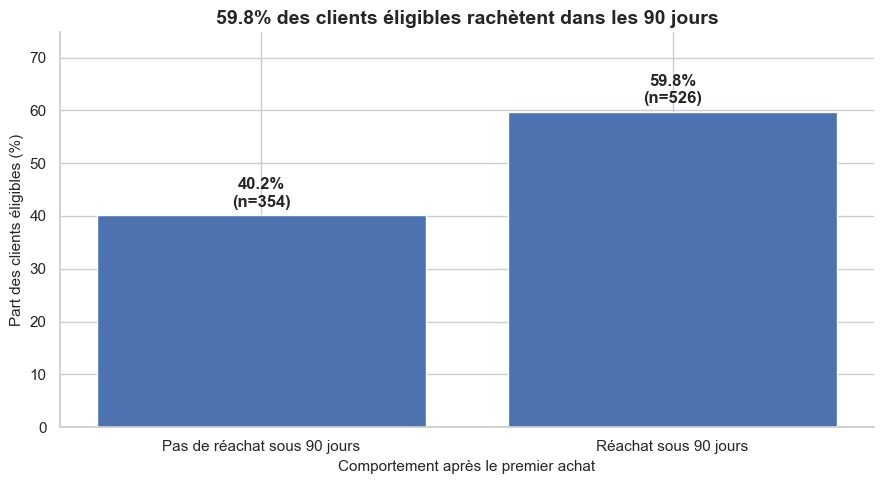

In [18]:
# ANALYSE 1  TAUX GLOBAL DE RÉACHAT


n_clients = (
    clients_eligibles["client_id"].nunique()
)

n_reacheteurs = int(
    clients_eligibles["reachat_90j"].sum()
)

taux_reachat = (
    100
    * n_reacheteurs
    / n_clients
)


delai_median = (
    clients_eligibles
    .loc[
        clients_eligibles["reachat_90j"],
        "delai_reachat_jours"
    ]
    .median()
)


resultat_reachat = pd.DataFrame({
    "Situation": [
        "Pas de réachat sous 90 jours",
        "Réachat sous 90 jours"
    ],
    "Clients": [
        n_clients - n_reacheteurs,
        n_reacheteurs
    ]
})


resultat_reachat["Part"] = (
    100
    * resultat_reachat["Clients"]
    / n_clients
)


display(
    resultat_reachat.round(1)
)


# Graphique


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    resultat_reachat["Situation"],
    resultat_reachat["Part"]
)


for bar, pct, n in zip(
    bars,
    resultat_reachat["Part"],
    resultat_reachat["Clients"]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{pct:.1f}%\n(n={n:,})",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


ax.set_title(
    f"{taux_reachat:.1f}% des clients éligibles "
    "rachètent dans les 90 jours"
)

ax.set_xlabel(
    "Comportement après le premier achat"
)

ax.set_ylabel(
    "Part des clients éligibles (%)"
)

ax.set_ylim(
    0,
    min(
        100,
        resultat_reachat["Part"].max() + 15
    )
)

sns.despine()

plt.tight_layout()
plt.show()

In [19]:
display(
    Markdown(
        f"""
### Commentaire

**Constat :** parmi **{n_clients:,} clients disposant de 90 jours complets d'observation**, **{n_reacheteurs:,}** effectuent une deuxième commande pendant cette période, soit **{taux_reachat:.1f} %**. Chez les clients qui rachètent, le délai médian avant le deuxième achat est de **{delai_median:.0f} jours**.

**Interprétation :** la fidélisation n'est donc pas automatique après un premier achat. Ce taux constitue notre niveau de référence pour comparer les différents profils de clients.

**Suite :** il faut vérifier si les clients qui rachètent sont également plus intéressants économiquement.
"""
    )
)


### Commentaire

**Constat :** parmi **880 clients disposant de 90 jours complets d'observation**, **526** effectuent une deuxième commande pendant cette période, soit **59.8 %**. Chez les clients qui rachètent, le délai médian avant le deuxième achat est de **28 jours**.

**Interprétation :** la fidélisation n'est donc pas automatique après un premier achat. Ce taux constitue notre niveau de référence pour comparer les différents profils de clients.

**Suite :** il faut vérifier si les clients qui rachètent sont également plus intéressants économiquement.


## Analyse 2 — Les clients qui rachètent génèrent-ils réellement plus de valeur ?

**Ce que je cherche :** déterminer si le réachat se traduit également par davantage de valeur économique.

**Indicateur et périmètre :** marge médiane cumulée au cours des 90 jours suivant le premier achat, comparée entre clients ayant racheté ou non.

La médiane est privilégiée à la moyenne afin de limiter l'influence de quelques clients ayant des achats exceptionnellement élevés.

,clients,ca_median_90j,marge_mediane_90j,commandes_medianes
Pas de réachat,354,63.86,29.96,1.0
Réachat ≤ 90 jours,526,261.87,103.47,3.0


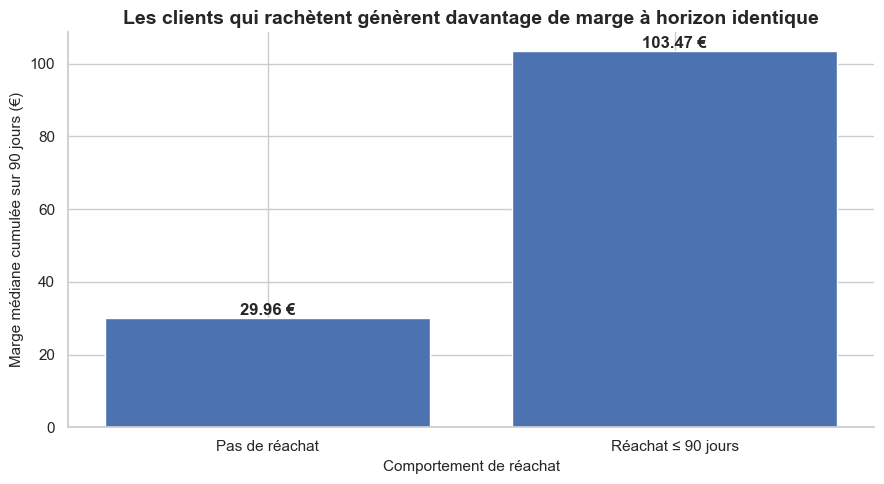

In [20]:
# ANALYSE 2 VALEUR ÉCONOMIQUE DU RÉACHAT


comparaison_valeur = (
    clients_eligibles
    .groupby(
        "reachat_90j"
    )
    .agg(
        clients=(
            "client_id",
            "nunique"
        ),
        ca_median_90j=(
            "ca_90j",
            "median"
        ),
        marge_mediane_90j=(
            "marge_90j",
            "median"
        ),
        commandes_medianes=(
            "nb_commandes_90j",
            "median"
        )
    )
    .reindex(
        [False, True]
    )
)


comparaison_valeur.index = [
    "Pas de réachat",
    "Réachat ≤ 90 jours"
]


display(
    comparaison_valeur.round(2)
)


marge_sans_reachat = (
    comparaison_valeur.loc[
        "Pas de réachat",
        "marge_mediane_90j"
    ]
)

marge_avec_reachat = (
    comparaison_valeur.loc[
        "Réachat ≤ 90 jours",
        "marge_mediane_90j"
    ]
)

difference_marge = (
    marge_avec_reachat
    - marge_sans_reachat
)


# Graphique


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    comparaison_valeur.index,
    comparaison_valeur["marge_mediane_90j"]
)


for bar, valeur in zip(
    bars,
    comparaison_valeur["marge_mediane_90j"]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{valeur:,.2f} €",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


ax.set_title(
    "Les clients qui rachètent génèrent "
    "davantage de marge à horizon identique"
)

ax.set_xlabel(
    "Comportement de réachat"
)

ax.set_ylabel(
    "Marge médiane cumulée sur 90 jours (€)"
)

sns.despine()

plt.tight_layout()
plt.show()

In [21]:
if marge_sans_reachat > 0:
    multiple = (
        marge_avec_reachat
        / marge_sans_reachat
    )

    texte_multiple = (
        f", soit environ **{multiple:.1f} fois** "
        "la marge des non-réacheteurs"
    )

else:
    texte_multiple = ""


display(
    Markdown(
        f"""
### Commentaire

**Constat :** les clients qui rachètent génèrent une marge médiane de **{marge_avec_reachat:,.2f} €** sur les 90 premiers jours, contre **{marge_sans_reachat:,.2f} €** pour ceux qui ne rachètent pas{texte_multiple}. L'écart atteint **{difference_marge:,.2f} € par client**.

**Interprétation :** la fidélisation est associée à une valeur économique supérieure. Cette comparaison est plus fiable qu'une comparaison sur toute la durée du dataset car chaque client est observé pendant exactement la même fenêtre temporelle.

**Suite :** il faut maintenant déterminer si certains canaux d'acquisition génèrent davantage de clients fidèles que d'autres.
"""
    )
)


### Commentaire

**Constat :** les clients qui rachètent génèrent une marge médiane de **103.47 €** sur les 90 premiers jours, contre **29.96 €** pour ceux qui ne rachètent pas, soit environ **3.5 fois** la marge des non-réacheteurs. L'écart atteint **73.51 € par client**.

**Interprétation :** la fidélisation est associée à une valeur économique supérieure. Cette comparaison est plus fiable qu'une comparaison sur toute la durée du dataset car chaque client est observé pendant exactement la même fenêtre temporelle.

**Suite :** il faut maintenant déterminer si certains canaux d'acquisition génèrent davantage de clients fidèles que d'autres.


## Analyse 3 — Tous les canaux d'acquisition ne génèrent pas la même fidélisation

**Ce que je cherche :** comparer la qualité des clients acquis par les différents canaux marketing.

**Indicateur et périmètre :** taux de réachat à 90 jours parmi les clients éligibles, calculé pour chaque canal d'acquisition.

Les pourcentages sont accompagnés de leurs effectifs et seuls les canaux comptant au moins **25 clients** sont interprétés.

,canal_acquisition,n_clients,n_reacheteurs,taux_reachat,marge_mediane_90j
3,Réseaux sociaux,327,203,62.08,69.20
2,Publicité en ligne,179,110,61.45,60.92
0,Bouche-à-oreille,106,61,57.55,74.00
1,Moteur de recherche,268,152,56.72,65.38


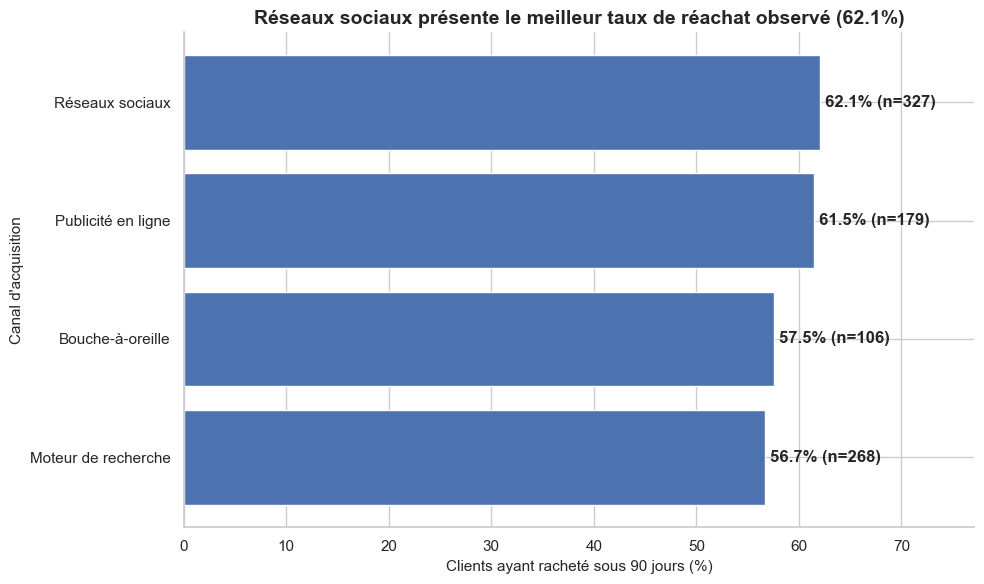

In [ ]:
# ANALYSE 3 - CANAL D'ACQUISITION


par_canal = (
    clients_eligibles
    .dropna(
        subset=["canal_acquisition"]
    )
    .groupby(
        "canal_acquisition",
        as_index=False
    )
    .agg(
        n_clients=(
            "client_id",
            "nunique"
        ),
        n_reacheteurs=(
            "reachat_90j",
            "sum"
        ),
        marge_mediane_90j=(
            "marge_90j",
            "median"
        )
    )
)


par_canal["taux_reachat"] = (
    100
    * par_canal["n_reacheteurs"]
    / par_canal["n_clients"]
)


# Effectif minimum
par_canal_solide = (
    par_canal[
        par_canal["n_clients"] >= 25
    ]
    .sort_values(
        "taux_reachat",
        ascending=False
    )
    .copy()
)


if par_canal_solide.empty:
    raise ValueError(
        "Aucun canal d'acquisition ne contient au moins 25 clients éligibles."
    )


display(
    par_canal_solide[
        [
            "canal_acquisition",
            "n_clients",
            "n_reacheteurs",
            "taux_reachat",
            "marge_mediane_90j"
        ]
    ].round(2)
)

# Graphique


plot_canal = (
    par_canal_solide
    .sort_values(
        "taux_reachat"
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    plot_canal["canal_acquisition"],
    plot_canal["taux_reachat"]
)


for bar, taux, n in zip(
    bars,
    plot_canal["taux_reachat"],
    plot_canal["n_clients"]
):
    ax.text(
        taux + 0.5,
        bar.get_y()
        + bar.get_height() / 2,
        f"{taux:.1f}% (n={n})",
        va="center",
        fontweight="bold"
    )


meilleur_canal = (
    par_canal_solide.iloc[0]
)


ax.set_title(
    f"{meilleur_canal['canal_acquisition']} présente "
    f"le meilleur taux de réachat observé "
    f"({meilleur_canal['taux_reachat']:.1f}%)"
)

ax.set_xlabel(
    "Clients ayant racheté sous 90 jours (%)"
)

ax.set_ylabel(
    "Canal d'acquisition"
)

ax.set_xlim(
    0,
    min(
        100,
        plot_canal["taux_reachat"].max() + 15
    )
)

sns.despine()

plt.tight_layout()
plt.show()

In [23]:
canal_best = (
    meilleur_canal["canal_acquisition"]
)

taux_canal_best = (
    meilleur_canal["taux_reachat"]
)

n_canal_best = int(
    meilleur_canal["n_clients"]
)

marge_canal_best = (
    meilleur_canal["marge_mediane_90j"]
)


display(
    Markdown(
        f"""
### Commentaire

**Constat :** parmi les canaux comptant au moins 25 clients éligibles, **{canal_best}** présente le taux de réachat à 90 jours le plus élevé avec **{taux_canal_best:.1f} %**, sur **{n_canal_best} clients**. Ces clients génèrent une marge médiane de **{marge_canal_best:,.2f} €** sur leurs 90 premiers jours.

**Interprétation :** les canaux d'acquisition ne semblent donc pas attirer des clients de même qualité en matière de fidélisation. Pour une décision marketing, le volume de nouveaux clients ne devrait pas être le seul indicateur : leur réachat et leur marge future doivent aussi être pris en compte.

**Limite :** les coûts publicitaires de chaque canal ne sont pas disponibles. Il est donc impossible de déterminer ici quel canal possède le meilleur retour sur investissement marketing.
"""
    )
)


### Commentaire

**Constat :** parmi les canaux comptant au moins 25 clients éligibles, **Réseaux sociaux** présente le taux de réachat à 90 jours le plus élevé avec **62.1 %**, sur **327 clients**. Ces clients génèrent une marge médiane de **69.20 €** sur leurs 90 premiers jours.

**Interprétation :** les canaux d'acquisition ne semblent donc pas attirer des clients de même qualité en matière de fidélisation. Pour une décision marketing, le volume de nouveaux clients ne devrait pas être le seul indicateur : leur réachat et leur marge future doivent aussi être pris en compte.

**Limite :** les coûts publicitaires de chaque canal ne sont pas disponibles. Il est donc impossible de déterminer ici quel canal possède le meilleur retour sur investissement marketing.


## Analyse 4 — Le contexte du premier achat est associé à la fidélisation

**Ce que je cherche :** identifier les caractéristiques du premier achat associées au plus fort taux de réachat.

Deux dimensions sont observées :

1. la catégorie ayant représenté le plus de chiffre d'affaires lors de la première commande ;
2. la remise effective accordée lors de cette première commande.

Les résultats restent descriptifs : ils permettent d'identifier des associations, mais pas de démontrer qu'une catégorie ou une remise provoque le réachat.

,categorie_entree,n_clients,n_reacheteurs,marge_mediane_90j,taux_reachat
0,Beauté,138,87,67.01,63.04
5,Électronique,119,73,84.24,61.34
2,Maison,161,98,74.18,60.87
1,Livres,119,71,30.16,59.66
3,Mode,209,121,69.67,57.89
4,Sport,134,76,59.92,56.72


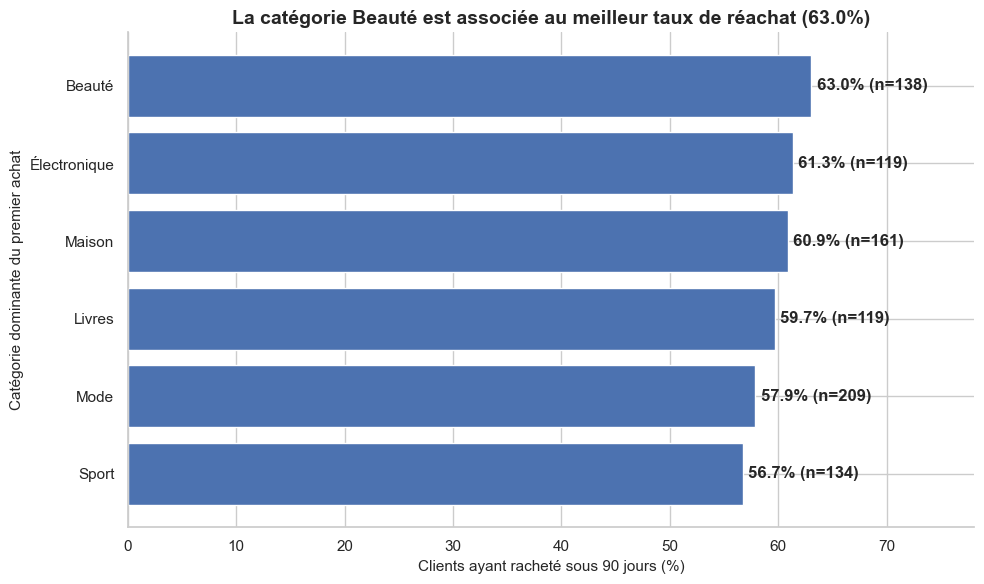

In [25]:
# ANALYSE 4.1 CATÉGORIE DU PREMIER ACHAT

par_categorie = (
    clients_eligibles
    .dropna(
        subset=["categorie_entree"]
    )
    .groupby(
        "categorie_entree",
        as_index=False
    )
    .agg(
        n_clients=(
            "client_id",
            "nunique"
        ),
        n_reacheteurs=(
            "reachat_90j",
            "sum"
        ),
        marge_mediane_90j=(
            "marge_90j",
            "median"
        )
    )
)


par_categorie["taux_reachat"] = (
    100
    * par_categorie["n_reacheteurs"]
    / par_categorie["n_clients"]
)


categories_solides = (
    par_categorie[
        par_categorie["n_clients"] >= 25
    ]
    .sort_values(
        "taux_reachat",
        ascending=False
    )
    .copy()
)


if categories_solides.empty:
    raise ValueError(
        "Aucune catégorie ne contient au moins 25 clients éligibles."
    )


display(
    categories_solides.round(2)
)


plot_cat = (
    categories_solides
    .sort_values(
        "taux_reachat"
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    plot_cat["categorie_entree"],
    plot_cat["taux_reachat"]
)


for bar, taux, n in zip(
    bars,
    plot_cat["taux_reachat"],
    plot_cat["n_clients"]
):
    ax.text(
        taux + 0.5,
        bar.get_y()
        + bar.get_height() / 2,
        f"{taux:.1f}% (n={n})",
        va="center",
        fontweight="bold"
    )


meilleure_categorie = (
    categories_solides.iloc[0]
)


ax.set_title(
    f"La catégorie {meilleure_categorie['categorie_entree']} "
    f"est associée au meilleur taux de réachat "
    f"({meilleure_categorie['taux_reachat']:.1f}%)"
)

ax.set_xlabel(
    "Clients ayant racheté sous 90 jours (%)"
)

ax.set_ylabel(
    "Catégorie dominante du premier achat"
)

ax.set_xlim(
    0,
    min(
        100,
        plot_cat["taux_reachat"].max() + 15
    )
)

sns.despine()

plt.tight_layout()
plt.show()

,tranche_remise,n_clients,n_reacheteurs,marge_mediane_90j,taux_reachat
0,Aucune remise,632,377,71.74,59.65
1,> 0 à 10 %,148,84,50.34,56.76
2,> 10 à 20 %,98,63,50.86,64.29


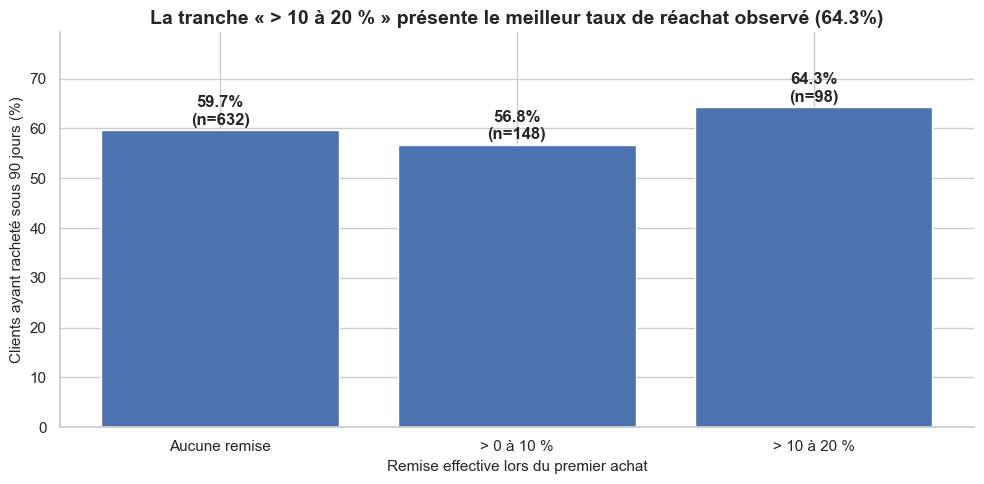

In [26]:

# ANALYSE 4.2  REMISE DU PREMIER ACHAT


clients_eligibles["tranche_remise"] = pd.cut(
    clients_eligibles["remise_premiere"],
    bins=[
        -0.000001,
        0.000001,
        0.10,
        0.20,
        1.000001
    ],
    labels=[
        "Aucune remise",
        "> 0 à 10 %",
        "> 10 à 20 %",
        "> 20 %"
    ],
    include_lowest=True
)


par_remise = (
    clients_eligibles
    .dropna(
        subset=["tranche_remise"]
    )
    .groupby(
        "tranche_remise",
        observed=True,
        as_index=False
    )
    .agg(
        n_clients=(
            "client_id",
            "nunique"
        ),
        n_reacheteurs=(
            "reachat_90j",
            "sum"
        ),
        marge_mediane_90j=(
            "marge_90j",
            "median"
        )
    )
)


par_remise["taux_reachat"] = (
    100
    * par_remise["n_reacheteurs"]
    / par_remise["n_clients"]
)


remises_solides = (
    par_remise[
        par_remise["n_clients"] >= 25
    ]
    .copy()
)


if remises_solides.empty:
    raise ValueError(
        "Aucune tranche de remise ne contient au moins 25 clients."
    )


display(
    remises_solides.round(2)
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)

bars = ax.bar(
    remises_solides[
        "tranche_remise"
    ].astype(str),
    remises_solides[
        "taux_reachat"
    ]
)


for bar, taux, n in zip(
    bars,
    remises_solides["taux_reachat"],
    remises_solides["n_clients"]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{taux:.1f}%\n(n={n})",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


meilleure_remise = (
    remises_solides
    .sort_values(
        "taux_reachat",
        ascending=False
    )
    .iloc[0]
)


ax.set_title(
    f"La tranche « {meilleure_remise['tranche_remise']} » "
    f"présente le meilleur taux de réachat observé "
    f"({meilleure_remise['taux_reachat']:.1f}%)"
)

ax.set_xlabel(
    "Remise effective lors du premier achat"
)

ax.set_ylabel(
    "Clients ayant racheté sous 90 jours (%)"
)

ax.set_ylim(
    0,
    min(
        100,
        remises_solides["taux_reachat"].max() + 15
    )
)

sns.despine()

plt.tight_layout()
plt.show()

In [27]:
cat_best = (
    meilleure_categorie["categorie_entree"]
)

cat_taux = (
    meilleure_categorie["taux_reachat"]
)

cat_n = int(
    meilleure_categorie["n_clients"]
)


remise_best = str(
    meilleure_remise["tranche_remise"]
)

remise_taux = (
    meilleure_remise["taux_reachat"]
)

remise_n = int(
    meilleure_remise["n_clients"]
)

remise_marge = (
    meilleure_remise["marge_mediane_90j"]
)


display(
    Markdown(
        f"""
### Commentaire

**Constat :** parmi les catégories suffisamment représentées, **{cat_best}** possède le taux de réachat le plus élevé avec **{cat_taux:.1f} %** sur **{cat_n} clients**. Concernant les promotions, la tranche **{remise_best}** présente le meilleur taux observé, avec **{remise_taux:.1f} %** sur **{remise_n} clients**.

**Interprétation :** le contexte du premier achat semble donc associé à la fidélisation. Néanmoins, une promotion n'est intéressante que si les achats supplémentaires compensent le coût de la remise. La marge médiane sur 90 jours du groupe **{remise_best}** est de **{remise_marge:,.2f} €**.

**Limite :** ces données sont observationnelles. On ne peut pas conclure que la catégorie ou la remise provoque le réachat. Les clients recevant une promotion peuvent par exemple avoir un profil différent des autres clients.

**Suite :** un test A/B sur les remises permettrait de mesurer un véritable effet causal.
"""
    )
)


### Commentaire

**Constat :** parmi les catégories suffisamment représentées, **Beauté** possède le taux de réachat le plus élevé avec **63.0 %** sur **138 clients**. Concernant les promotions, la tranche **> 10 à 20 %** présente le meilleur taux observé, avec **64.3 %** sur **98 clients**.

**Interprétation :** le contexte du premier achat semble donc associé à la fidélisation. Néanmoins, une promotion n'est intéressante que si les achats supplémentaires compensent le coût de la remise. La marge médiane sur 90 jours du groupe **> 10 à 20 %** est de **50.87 €**.

**Limite :** ces données sont observationnelles. On ne peut pas conclure que la catégorie ou la remise provoque le réachat. Les clients recevant une promotion peuvent par exemple avoir un profil différent des autres clients.

**Suite :** un test A/B sur les remises permettrait de mesurer un véritable effet causal.


In [28]:
# ============================================================
# CONCLUSION FINALE
# ============================================================

display(
    Markdown(
        f"""
# Conclusion

### Réponse à la problématique

Parmi **{n_clients:,} clients disposant de 90 jours complets d'observation**, **{taux_reachat:.1f} %** réalisent une deuxième commande dans les 90 jours suivant leur premier achat.

La fidélisation possède un intérêt économique réel : les clients qui rachètent génèrent une marge médiane de **{marge_avec_reachat:,.2f} €** sur cette période, contre **{marge_sans_reachat:,.2f} €** chez ceux qui ne rachètent pas, soit un écart de **{difference_marge:,.2f} € par client**.

Le canal **{canal_best}** présente le meilleur taux de réachat observé parmi les canaux suffisamment représentés, avec **{taux_canal_best:.1f} %**. La catégorie d'entrée **{cat_best}** obtient quant à elle **{cat_taux:.1f} %** de réachat à 90 jours.

Enfin, la tranche de remise **{remise_best}** présente le taux de réachat observé le plus élevé (**{remise_taux:.1f} %**), mais cette association ne permet pas d'affirmer qu'une remise provoque la fidélisation.

### Limites

L'étude repose sur des données observationnelles : elle met en évidence des associations mais pas des relations causales.

Le coût marketing des différents canaux d'acquisition n'est pas disponible. Il est donc impossible de comparer leur rentabilité réelle ou leur coût d'acquisition client.

La fidélisation est volontairement limitée à 90 jours. Des comportements de réachat plus tardifs peuvent donc ne pas être comptabilisés.

Enfin, la catégorie d'entrée correspond à la catégorie représentant le plus de chiffre d'affaires lors de la première commande, ce qui simplifie les paniers comportant plusieurs catégories.

### Si j'avais plus de temps

Je construirais un modèle de probabilité de réachat intégrant simultanément le canal d'acquisition, la catégorie, la remise, l'âge, la ville et le montant du premier panier.

J'ajouterais également les dépenses publicitaires afin de calculer le coût d'acquisition et la valeur client par canal.

Enfin, un test A/B sur différents niveaux de remise permettrait de déterminer si les promotions augmentent réellement le réachat, plutôt que de constater uniquement une corrélation.
"""
    )
)


# Conclusion

### Réponse à la problématique

Parmi **880 clients disposant de 90 jours complets d'observation**, **59.8 %** réalisent une deuxième commande dans les 90 jours suivant leur premier achat.

La fidélisation possède un intérêt économique réel : les clients qui rachètent génèrent une marge médiane de **103.47 €** sur cette période, contre **29.96 €** chez ceux qui ne rachètent pas, soit un écart de **73.51 € par client**.

Le canal **Réseaux sociaux** présente le meilleur taux de réachat observé parmi les canaux suffisamment représentés, avec **62.1 %**. La catégorie d'entrée **Beauté** obtient quant à elle **63.0 %** de réachat à 90 jours.

Enfin, la tranche de remise **> 10 à 20 %** présente le taux de réachat observé le plus élevé (**64.3 %**), mais cette association ne permet pas d'affirmer qu'une remise provoque la fidélisation.

### Limites

L'étude repose sur des données observationnelles : elle met en évidence des associations mais pas des relations causales.

Le coût marketing des différents canaux d'acquisition n'est pas disponible. Il est donc impossible de comparer leur rentabilité réelle ou leur coût d'acquisition client.

La fidélisation est volontairement limitée à 90 jours. Des comportements de réachat plus tardifs peuvent donc ne pas être comptabilisés.

Enfin, la catégorie d'entrée correspond à la catégorie représentant le plus de chiffre d'affaires lors de la première commande, ce qui simplifie les paniers comportant plusieurs catégories.

### Si j'avais plus de temps

Je construirais un modèle de probabilité de réachat intégrant simultanément le canal d'acquisition, la catégorie, la remise, l'âge, la ville et le montant du premier panier.

J'ajouterais également les dépenses publicitaires afin de calculer le coût d'acquisition et la valeur client par canal.

Enfin, un test A/B sur différents niveaux de remise permettrait de déterminer si les promotions augmentent réellement le réachat, plutôt que de constater uniquement une corrélation.


In [30]:
# CHECK FINAL DU NOTEBOOK


assert n_clients > 0
assert 0 <= taux_reachat <= 100

assert clients_eligibles["client_id"].is_unique, \
    "Un client apparaît plusieurs fois dans la table finale."

assert clients_eligibles["eligible_90j"].all(), \
    "Des clients sans 90 jours complets sont présents."

assert clients_eligibles["nb_commandes_90j"].ge(1).all(), \
    "Un client possède moins d'une commande dans sa fenêtre."

assert clients_eligibles["reachat_90j"].isin(
    [True, False]
).all()


print("Tous les contrôles finaux sont validés.")
print("L'unité statistique finale est bien le client.")
print("Les pourcentages de réachat utilisent des clients uniques.")
print("Tous les clients possèdent 90 jours complets d'observation.")
print("Notebook prêt pour Restart & Run All.")

Tous les contrôles finaux sont validés.
L'unité statistique finale est bien le client.
Les pourcentages de réachat utilisent des clients uniques.
Tous les clients possèdent 90 jours complets d'observation.
Notebook prêt pour Restart & Run All.
